In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [3]:
#Menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [4]:
#Memanggil data set lewat gdrive
path = "/content/gdrive/MyDrive/Praktikum-Tugas_MachineLearning/Praktikum12"

In [5]:
df = pd.read_csv('/content/gdrive/MyDrive/Praktikum-Tugas_MachineLearning/Praktikum12/Data/data.csv')

In [6]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [8]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [9]:
# Muat dataset Breast Cancer dari sklearn
cancer = load_breast_cancer()

In [10]:
# Buat DataFrame dari data fitur
df = pd.DataFrame(cancer['data'], columns=cancer['feature_names'])

In [11]:
# Tambahkan kolom target (0=Ganas/Malignant, 1=Jinak/Benign)
df['target'] = cancer['target']

In [12]:
# Pemeriksaan Data Awal (EDA)
print("--- df.head() ---")
print(df.head())
print("\n--- df.info() ---")
df.info()
print("\n--- df.describe() ---")
print(df.describe())
print("\n--- Distribusi Kelas ---")
print(df['target'].value_counts())

--- df.head() ---
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area

In [13]:
# Pisahkan fitur (X) dan target (y)
X = df.drop('target', axis=1)
y = df['target']

In [14]:
# Inisialisasi dan Terapkan StandardScaler
# StandardScaler membuat data memiliki rata-rata 0 dan standar deviasi 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data fitur berhasil di-scaling.")
print(f"Bentuk data fitur setelah scaling: {X_scaled.shape}")

Data fitur berhasil di-scaling.
Bentuk data fitur setelah scaling: (569, 30)


In [15]:
# Inisialisasi PCA dengan 2 komponen
pca_2d = PCA(n_components=2)

# Terapkan PCA pada data yang sudah di-scaling
principal_components = pca_2d.fit_transform(X_scaled)

In [16]:
# Buat DataFrame baru untuk visualisasi
pca_df = pd.DataFrame(data = principal_components,
                      columns = ['Principal Component 1', 'Principal Component 2'])
pca_df['target'] = y

print("PCA berhasil diterapkan ke 2 komponen.")
print(pca_df.head())

PCA berhasil diterapkan ke 2 komponen.
   Principal Component 1  Principal Component 2  target
0               9.192837               1.948583       0
1               2.387802              -3.768172       0
2               5.733896              -1.075174       0
3               7.122953              10.275589       0
4               3.935302              -1.948072       0


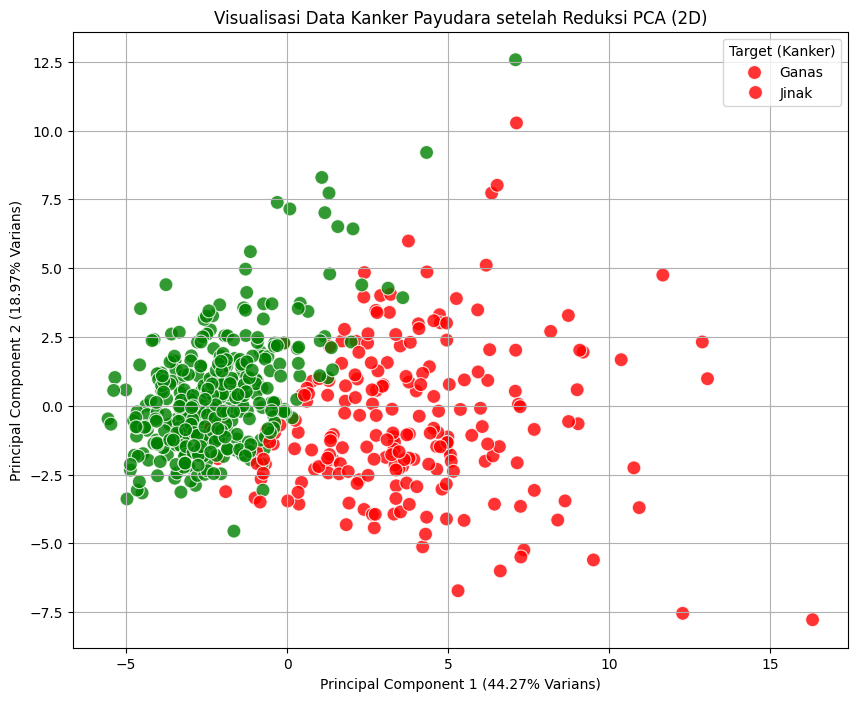

In [17]:
# Visualisasi 2 Principal Components
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1',
                y='Principal Component 2',
                hue='target',
                data=pca_df,
                palette={0: 'red', 1: 'green'}, # 0: Malignant, 1: Benign
                alpha=0.8,
                s=100)

plt.title('Visualisasi Data Kanker Payudara setelah Reduksi PCA (2D)')
plt.xlabel(f'Principal Component 1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% Varians)')
plt.ylabel(f'Principal Component 2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% Varians)')
plt.legend(title='Target (Kanker)', labels=['Ganas', 'Jinak'])
plt.grid(True)
plt.show()

In [18]:
# Total varians yang dijelaskan oleh 2 komponen
total_variance_2d = pca_2d.explained_variance_ratio_.sum() * 100
print(f"Total varians yang dijelaskan oleh 2 komponen: {total_variance_2d:.2f}%")

Total varians yang dijelaskan oleh 2 komponen: 63.24%


In [28]:
pca_full = PCA()
pca_full.fit(X_scaled)

PCA()

In [26]:
# Hitung kumulatif variance explained
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

Text(0, 0.5, 'Kumulatif Varians yang Dijelaskan')

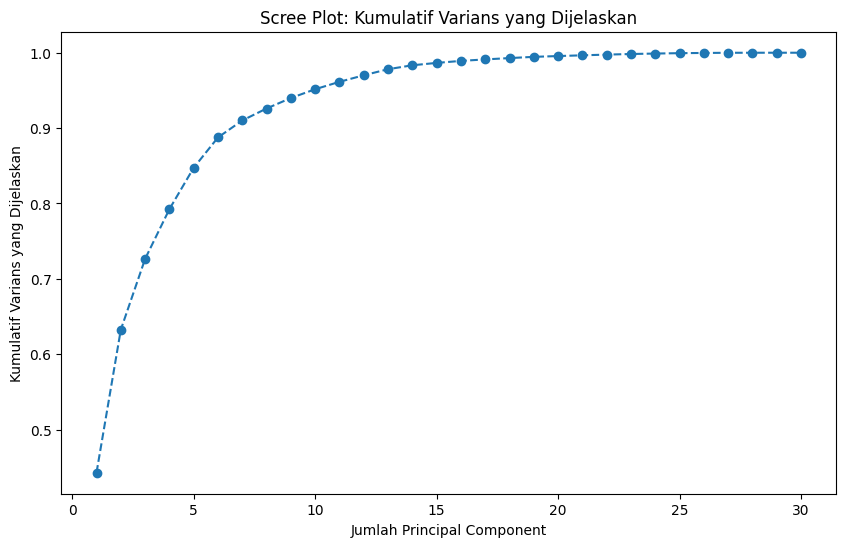

In [20]:
# Plot Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Scree Plot: Kumulatif Varians yang Dijelaskan')
plt.xlabel('Jumlah Principal Component')
plt.ylabel('Kumulatif Varians yang Dijelaskan')

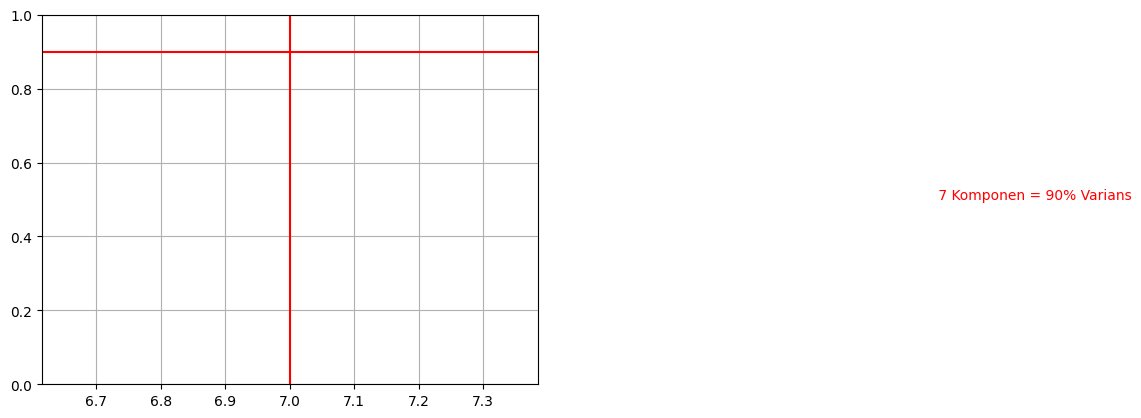

Jumlah komponen yang menjelaskan >90% varians adalah: 7


In [21]:
# Cari varians mencapai 90%
threshold = 0.90
optimal_n = np.where(cumulative_variance >= threshold)[0][0] + 1
plt.axvline(x=optimal_n, color='r', linestyle='-')
plt.axhline(y=threshold, color='r', linestyle='-')
plt.text(optimal_n + 1, 0.5, f' {optimal_n} Komponen = {threshold*100:.0f}% Varians', color='red')
plt.grid(True)
plt.show()

print(f"Jumlah komponen yang menjelaskan >{threshold*100:.0f}% varians adalah: {optimal_n}")

In [22]:
# Gunakan N_COMPONENTS hasil dari Scree Plot (misal: 5)
N_COMPONENTS = optimal_n

# Terapkan PCA dengan N_COMPONENTS yang optimal
pca_final = PCA(n_components=N_COMPONENTS)
X_pca = pca_final.fit_transform(X_scaled)

print(f"Data direduksi dari 30 fitur menjadi {N_COMPONENTS} fitur.")

Data direduksi dari 30 fitur menjadi 7 fitur.


In [23]:
# Bagi data menjadi training dan testing set
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)



In [24]:
# Latih Model Logistic Regression
model_pca = LogisticRegression(solver='liblinear', random_state=42)
model_pca.fit(X_train_pca, y_train)

LogisticRegression(random_state=42, solver='liblinear')

In [25]:
# Prediksi dan Evaluasi
y_pred_pca = model_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)

print(f"\n--- Evaluasi Model Klasifikasi dengan PCA (N={N_COMPONENTS}) ---")
print(f"Akurasi: {accuracy_pca:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca))


--- Evaluasi Model Klasifikasi dengan PCA (N=7) ---
Akurasi: 0.9883

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        63
           1       0.99      0.99      0.99       108

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171

